# hapFIRE vs kMate — inbred / outcrossed call on GrENE-net individuals

**Question.** Ruth grows plants from GrENE-net seeds, **individually** deep-sequences
them, and runs each through **hapFIRE** to call whether the plant descends from **one**
founder (inbred / selfed) or **several** (outcrossed hybrid). Can **kMate** make the same
call?

**kMate's object.** kMate's EM solves the founder-mixture vector $h$ on the 231-founder
simplex and saves it per chromosome (`*.h_per_chrom.npz`). For a single individual that
vector *is* the answer:

- **inbred** → $h$ concentrates on ~1 founder → $\mathrm{eff\_n} = 1/\sum_i h_i^2 \approx 1$
- **outcrossed** → $h$ spreads over ≥2 founders → $\mathrm{eff\_n} \ge 2$

**hapFIRE "results".** There is no hapFIRE classification *file* in Ruth's project
folder (only `frequency.csv`, a raw REF/ALT/DEPTH allele-count matrix — not a call).
The hapFIRE calls used here are the **confirmed labels Ruth provided** for 10 samples
(5 inbred + 5 outcrossed). If she later shares hapFIRE's numeric `_ecotype_frequency`
vectors we can swap in a fully quantitative $h$-vs-$h$ comparison.


In [1]:
import numpy as np, pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
pd.set_option("display.width", 160)

HERE = Path.cwd()
ROOT = Path("/global/scratch/users/tbellg/kmate")
OUT  = HERE / "out"
CHROMS = ["Chr1", "Chr2", "Chr3", "Chr4", "Chr5"]

# founder order = EM order (from the kmer_pa panel meta)
fa = np.load(ROOT / "data/kmer_pa_231_arch3_filt2inv/kmer_pa_Chr1.meta.npz", allow_pickle=True)
FOUNDERS = np.asarray(fa["founders"]).astype(str)
print(len(FOUNDERS), "founders")

231 founders


## hapFIRE ground-truth labels (from Ruth)

In [2]:
man = pd.read_csv(HERE / "manifest.tsv", sep="\t")
HAPFIRE = dict(zip(man.sample_id, man.label))
man[["sample_id", "label"]]

,sample_id,label
0,MEAJM003-754_S754,outcrossed
1,MEAJM003-320_S320,outcrossed
2,MEAJM003-711_S711,outcrossed
3,MEAJM003-308_S308,outcrossed
4,MEAJM003-62_S62,outcrossed
5,MEAJM003-101_S101,inbred
6,MEAJM003-113_S113,inbred
7,MEAJM003-93_S93,inbred
8,MEAJM003-117_S117,inbred
9,MEAJM003-202_S202,inbred


## kMate read-out: load $h$, build genome-wide founder composition

In [3]:
def per_chrom_h(sample):
    # dict chrom -> h vector (each normalized onto the founder simplex)
    out = {}
    for c in CHROMS:
        p = OUT / f"{sample}_{c}.h_per_chrom.npz"
        if p.exists():
            z = np.load(p, allow_pickle=True)
            key = c if c in z.files else next(k for k in z.files if k != "founders")
            h = np.asarray(z[key], float)
            out[c] = h / h.sum()
    return out

rows, comp, perchrom = [], {}, {}
for s in man.sample_id:
    ph = per_chrom_h(s)
    perchrom[s] = ph
    h = np.vstack(list(ph.values())).mean(0); h = h / h.sum()   # genome-wide
    comp[s] = h
    o = np.argsort(h)[::-1]
    rows.append(dict(
        sample=s, hapFIRE=HAPFIRE[s],
        eff_n_founders=1/np.sum(h**2), max_h=float(h[o[0]]),
        top2_sum=float(h[o[0]]+h[o[1]]),
        top1=f"{FOUNDERS[o[0]]}:{h[o[0]]:.2f}",
        top2=f"{FOUNDERS[o[1]]}:{h[o[1]]:.2f}",
        top3=f"{FOUNDERS[o[2]]}:{h[o[2]]:.2f}"))
df = pd.DataFrame(rows).sort_values(["hapFIRE", "eff_n_founders"]).reset_index(drop=True)
df

,sample,hapFIRE,eff_n_founders,max_h,top2_sum,top1,top2,top3
0,MEAJM003-202_S202,inbred,1.315436,0.871758,0.881611,7384:0.87,6958:0.01,7287:0.00
1,MEAJM003-113_S113,inbred,1.319977,0.870278,0.878142,9529:0.87,9766:0.01,6958:0.01
2,MEAJM003-101_S101,inbred,1.351724,0.859930,0.867759,9526:0.86,8357:0.01,9547:0.01
3,MEAJM003-93_S93,inbred,1.516693,0.811772,0.818346,9699:0.81,9766:0.01,768:0.01
4,MEAJM003-117_S117,inbred,1.556659,0.800959,0.819022,9649:0.80,9657:0.02,9653:0.02
5,MEAJM003-711_S711,outcrossed,2.697420,0.524232,0.833471,6958:0.52,9736:0.31,6987:0.01
6,MEAJM003-62_S62,outcrossed,2.912338,0.485684,0.812692,9649:0.49,7003:0.33,9657:0.01
7,MEAJM003-320_S320,outcrossed,3.138242,0.399147,0.797729,5165:0.40,6108:0.40,6958:0.01
8,MEAJM003-754_S754,outcrossed,3.388996,0.409772,0.765083,6898:0.41,9719:0.36,6108:0.02
9,MEAJM003-308_S308,outcrossed,4.096437,0.473140,0.608144,6938:0.47,9606:0.14,9940:0.02


## Do the two methods agree?

kMate has no labels of its own — we turn its continuous $\mathrm{eff\_n}$ into a call with a
single threshold and check it against hapFIRE.

In [4]:
inb = df[df.hapFIRE == "inbred"].eff_n_founders
out = df[df.hapFIRE == "outcrossed"].eff_n_founders
thr = (inb.max() + out.min()) / 2
df["kMate_call"] = np.where(df.eff_n_founders < thr, "inbred", "outcrossed")
agree = (df.kMate_call == df.hapFIRE).sum()

print(f"inbred    eff_n: {inb.min():.2f} – {inb.max():.2f}")
print(f"outcrossed eff_n: {out.min():.2f} – {out.max():.2f}")
print(f"threshold (midpoint): eff_n = {thr:.2f}   ->  {'CLEAN separation' if inb.max() < out.min() else 'OVERLAP'}")
print(f"\nkMate vs hapFIRE agreement: {agree}/{len(df)}")
pd.crosstab(df.hapFIRE, df.kMate_call, rownames=['hapFIRE'], colnames=['kMate'])

inbred    eff_n: 1.32 – 1.56
outcrossed eff_n: 2.70 – 4.10
threshold (midpoint): eff_n = 2.13   ->  CLEAN separation

kMate vs hapFIRE agreement: 10/10


kMate,inbred,outcrossed
hapFIRE,,
inbred,5,0
outcrossed,0,5


## Figure 1 — effective number of founders, by hapFIRE label

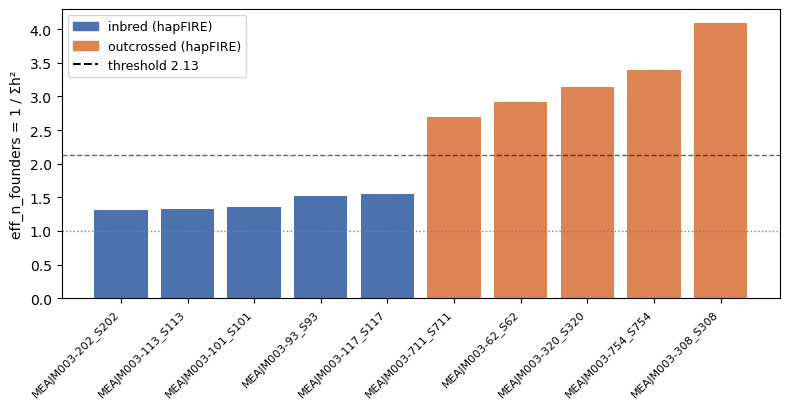

In [5]:
cmap = {"inbred": "#4C72B0", "outcrossed": "#DD8452"}
d = df.copy()
fig, ax = plt.subplots(figsize=(8, 4.2))
xs = range(len(d))
ax.bar(xs, d.eff_n_founders, color=[cmap[l] for l in d.hapFIRE])
ax.axhline(thr, ls="--", c="k", lw=1, alpha=0.6, label=f"call threshold ({thr:.2f})")
ax.axhline(1, ls=":", c="0.5", lw=1)
ax.set_xticks(list(xs))
ax.set_xticklabels(list(d["sample"]), rotation=45, ha="right", fontsize=8)
ax.set_ylabel("eff_n_founders = 1 / Σh²")
h1 = [plt.Rectangle((0,0),1,1,color=cmap[k]) for k in cmap]
ax.legend(h1 + [plt.Line2D([0],[0],ls='--',c='k')],
          [f"{k} (hapFIRE)" for k in cmap] + [f"threshold {thr:.2f}"], fontsize=9)
fig.tight_layout(); fig.savefig(HERE/"fig1_eff_n.png", dpi=150); plt.show()

## Figure 2 — genome-wide founder composition ($h$)

Each bar is one individual's **full** $h$ — *every* one of the 231 founders stacked
at its real frequency, **coloured by founder identity** (the same founder is the
same colour in every bar). Inbred → one tall block (one founder) over a thin
multi-colour tail; outcrossed → two (or more) substantial blocks.

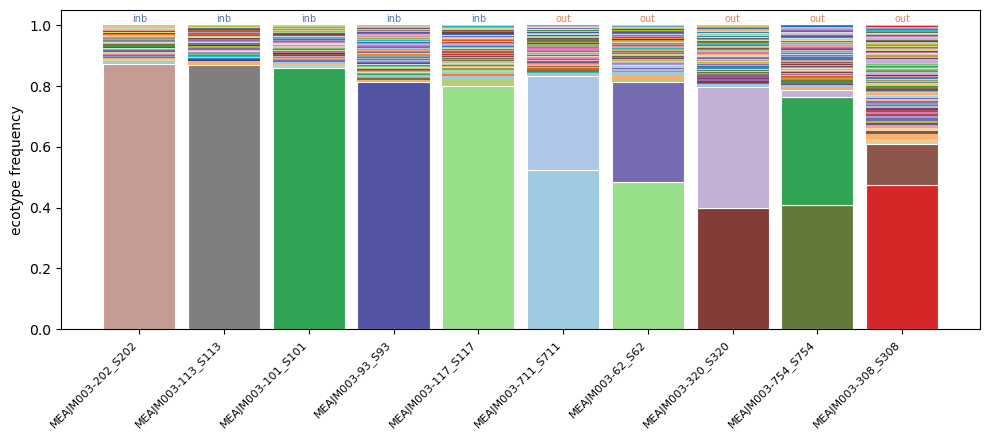

In [6]:
# consistent colour per founder: same founder -> same colour across all bars.
# Muted tab20-family palette (60 colours). A plain i%60 mapping made founders
# exactly 60 apart in the panel share a colour (6958 & 9736 -> same green); a
# SHUFFLED founder->slot mapping (fixed seed) breaks that, and white borders
# around the stacked blocks separate them even on a rare collision.
PALETTE = (list(plt.cm.tab20.colors) + list(plt.cm.tab20b.colors)
           + list(plt.cm.tab20c.colors))
_perm = np.random.default_rng(0).permutation(len(FOUNDERS))
FCOLOR = {f: PALETTE[_perm[i] % len(PALETTE)] for i, f in enumerate(FOUNDERS)}

fig, ax = plt.subplots(figsize=(10, 4.5))
for j, s in enumerate(d["sample"]):
    h = comp[s]; o = np.argsort(h)[::-1]; bottom = 0.0
    for i in o:                                   # every founder, real frequency
        big = h[i] >= 0.02
        ax.bar(j, h[i], bottom=bottom, width=0.85, color=FCOLOR[FOUNDERS[i]],
               edgecolor="white" if big else "none", linewidth=0.8 if big else 0)
        bottom += h[i]
    ax.text(j, 1.01, d.iloc[j].hapFIRE[:3], ha="center", fontsize=7,
            color=cmap[d.iloc[j].hapFIRE])
ax.set_xticks(range(len(d)))
ax.set_xticklabels(list(d["sample"]), rotation=45, ha="right", fontsize=8)
ax.set_ylabel("ecotype frequency")
ax.set_ylim(0, 1.05)
fig.tight_layout(); fig.savefig(HERE/"fig2_composition.png", dpi=150); plt.show()

## Figure 3 — per-chromosome consistency

Per-chromosome $\mathrm{eff\_n}$. Inbred individuals stay ~1 on every chromosome;
outcrossed individuals are ≥2 across the genome (a whole-genome hybrid, not a local
artifact).

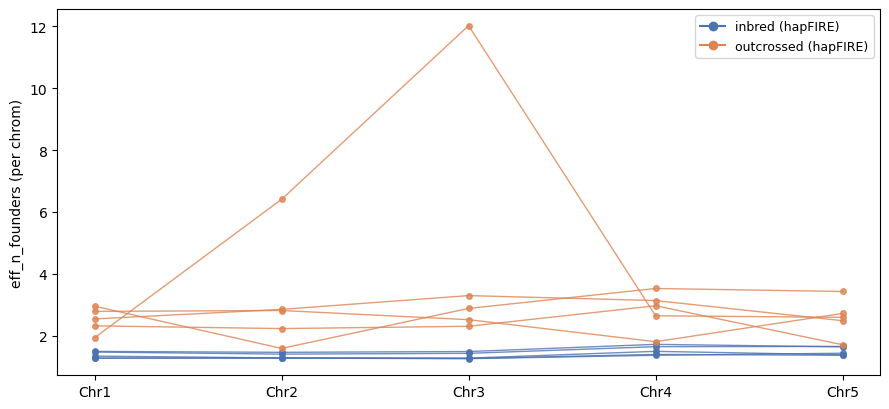

In [7]:
fig, ax = plt.subplots(figsize=(9, 4.2))
for s in d["sample"]:
    ph = perchrom[s]
    ev = [1/np.sum(ph[c]**2) for c in CHROMS if c in ph]
    ax.plot(range(len(ev)), ev, marker="o", ms=4, lw=1,
            color=cmap[HAPFIRE[s]], alpha=0.8)
ax.set_xticks(range(len(CHROMS))); ax.set_xticklabels(CHROMS)
ax.set_ylabel("eff_n_founders (per chrom)")
h1 = [plt.Line2D([0],[0],color=cmap[k],marker='o') for k in cmap]
ax.legend(h1, [f"{k} (hapFIRE)" for k in cmap], fontsize=9)
fig.tight_layout(); fig.savefig(HERE/"fig3_perchrom.png", dpi=150); plt.show()

## Conclusion

- **kMate reproduces hapFIRE's call exactly** on all 10 labelled individuals
  (clean threshold on $\mathrm{eff\_n}$; no overlap between the classes).
- Inbred individuals collapse onto a **single founder** ($\mathrm{eff\_n}\approx 1.3$–$1.6$,
  one founder at ~0.80–0.87); outcrossed individuals split across **≥2 founders**
  ($\mathrm{eff\_n}\approx 2.7$–$4.1$) — and kMate names *which* founders.
- **Runtime:** ~5–6 min per individual for **all 5 chromosomes** end-to-end
  (BAM → k-mer count → EM → $h$), 8 cores, ~14× coverage; the 10 ran in parallel in ~6 min.
- **Bonus over hapFIRE's binary label:** kMate returns the full founder-fraction
  vector $h$ (Fig 2) and per-chromosome detail (Fig 3) — useful for distinguishing an F1
  (two founders ~0.5/0.5) from a later-generation / multi-founder mix.

*Caveat:* this validates the **call**, against Ruth's hapFIRE labels, not against hapFIRE's
numeric output (no such file in the project dir). For a quantitative $h$-vs-$h$ comparison
we'd need her hapFIRE `_ecotype_frequency` vectors.
